In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Imbalance handling
from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv(r'C:\Users\MS994\Downloads\fds\depression_analysis_processed.csv')

print(df.head())
print(df.info())

                        timestamp  age  gender  stress  anxiety  sadness  \
0  2026/03/24 7:37:41 pm gmt+5:30   21  Female       4        3        3   
1  2026/03/24 7:41:03 pm gmt+5:30   21    Male       2        2        3   
2  2026/03/24 7:41:38 pm gmt+5:30   22  Female       0        2        2   
3  2026/03/24 7:47:09 pm gmt+5:30   21    Male       4        0        4   
4  2026/03/24 7:48:26 pm gmt+5:30   22    Male       3        3        3   

   overwhelmed  concentration  overthinking  mood_swings  ...  sleep  \
0            2              2             3            3  ...      1   
1            0              2             4            2  ...      1   
2            2              0             1            3  ...      2   
3            3              2             3            3  ...      2   
4            0              2             2            0  ...      1   

   emotional_score  cognitive_score  sleep_risk  physical_score  social_score  \
0         3.333333         2.

In [4]:
target = "risk_level"


y = df[target]
cols_to_remove = [
    "drs",
    "drs_raw",
    "emotional_score",
    "behavioral_score",
    "wellbeing"
]

X = df.drop(columns=cols_to_remove + ["risk_level"])

In [5]:
le = LabelEncoder()
y = le.fit_transform(y)

print(dict(zip(le.classes_, le.transform(le.classes_))))
X = pd.get_dummies(X, drop_first=True)

{'High': 0, 'Low': 1, 'Moderate': 2}


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
#handle class imbalance
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

After SMOTE: [357 357 357]


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
#1logestic regression
lr = LogisticRegression(multi_class='multinomial', max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [10]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Results")
    print("-" * 30)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Logistic Regression Results
------------------------------
Accuracy: 0.9316770186335404

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       0.86      0.88      0.87        42
           2       0.94      0.93      0.94        89

    accuracy                           0.93       161
   macro avg       0.93      0.94      0.94       161
weighted avg       0.93      0.93      0.93       161



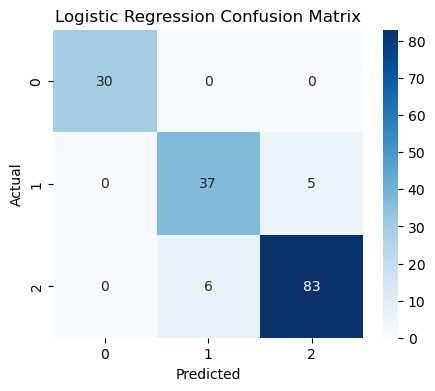

In [11]:
evaluate_model("Logistic Regression", y_test, y_pred_lr)

In [12]:
#decision tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


Decision Tree Results
------------------------------
Accuracy: 0.8571428571428571

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       0.72      0.74      0.73        42
           2       0.88      0.87      0.87        89

    accuracy                           0.86       161
   macro avg       0.87      0.87      0.87       161
weighted avg       0.86      0.86      0.86       161



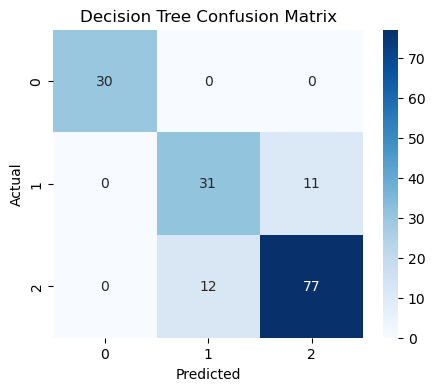

In [13]:
evaluate_model("Decision Tree", y_test, y_pred_dt)

In [14]:
#random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


Random Forest Results
------------------------------
Accuracy: 0.8944099378881988

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       0.86      0.71      0.78        42
           2       0.88      0.94      0.91        89

    accuracy                           0.89       161
   macro avg       0.91      0.89      0.90       161
weighted avg       0.89      0.89      0.89       161



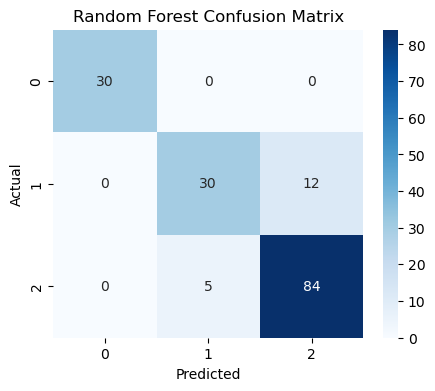

In [15]:
evaluate_model("Random Forest", y_test, y_pred_rf)

            Feature  Importance
13  cognitive_score    0.113353
15   physical_score    0.105189
16     social_score    0.097797
2           anxiety    0.091192
1            stress    0.084992
3           sadness    0.075225
8             tired    0.052516
11           coping    0.045342
14       sleep_risk    0.044969
6      overthinking    0.036485


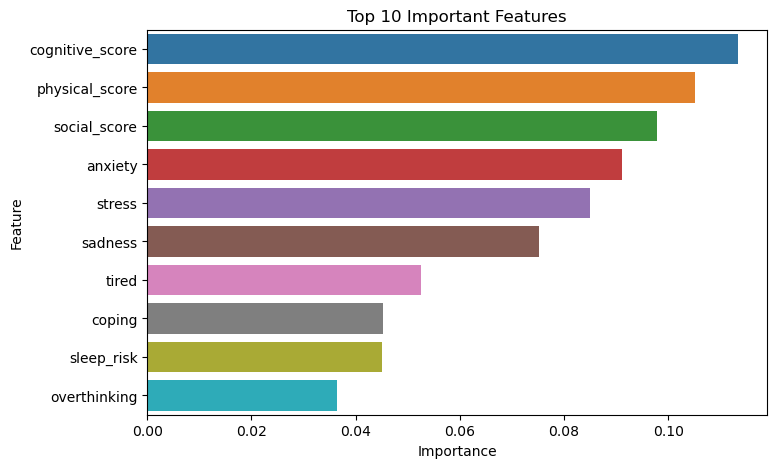

In [16]:
importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_df.head(10))

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

In [17]:
print(feat_df.head(5))

            Feature  Importance
13  cognitive_score    0.113353
15   physical_score    0.105189
16     social_score    0.097797
2           anxiety    0.091192
1            stress    0.084992


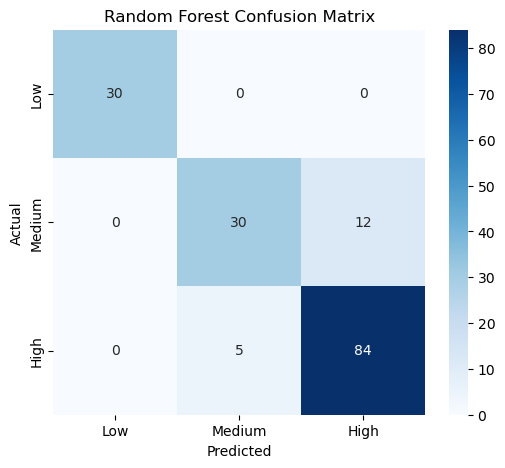

In [18]:
#visualization
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

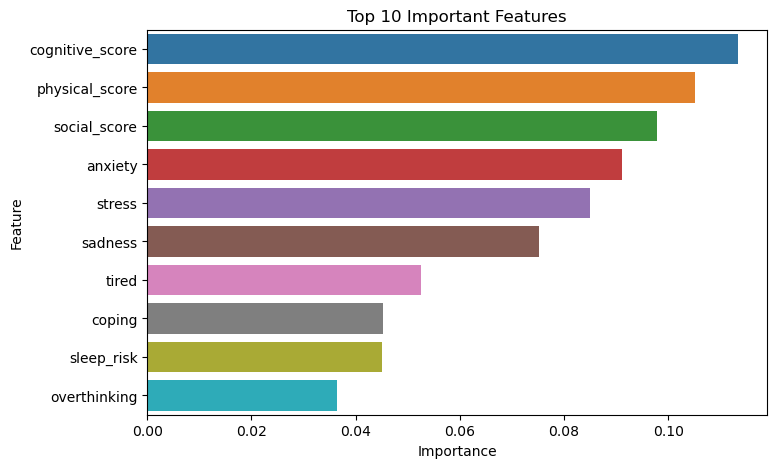

In [19]:
#feature importance
import pandas as pd

importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

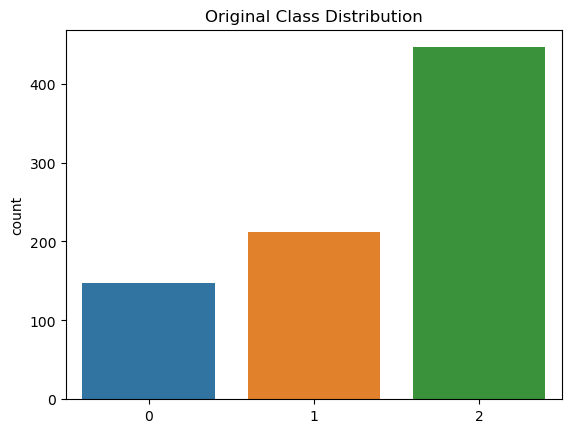

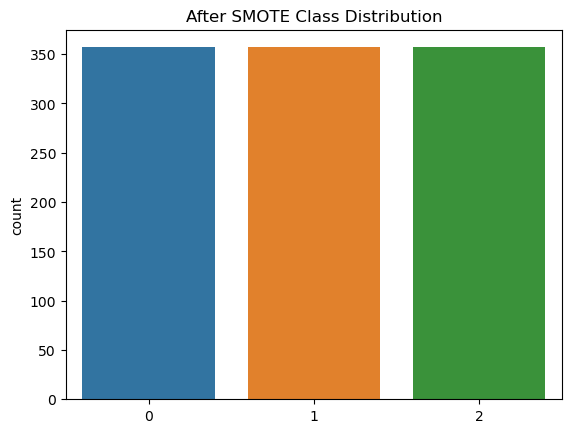

In [20]:
#handeling class imbalance - before and after visualization
# Before SMOTE
sns.countplot(x=y)
plt.title("Original Class Distribution")
plt.show()

# After SMOTE
sns.countplot(x=y_train)
plt.title("After SMOTE Class Distribution")
plt.show()

In [21]:
#Acutal vs predicted comparision
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf
})

print(comparison.head(10))

   Actual  Predicted
0       2          1
1       1          1
2       1          2
3       2          2
4       2          2
5       2          2
6       2          2
7       0          0
8       0          0
9       2          2


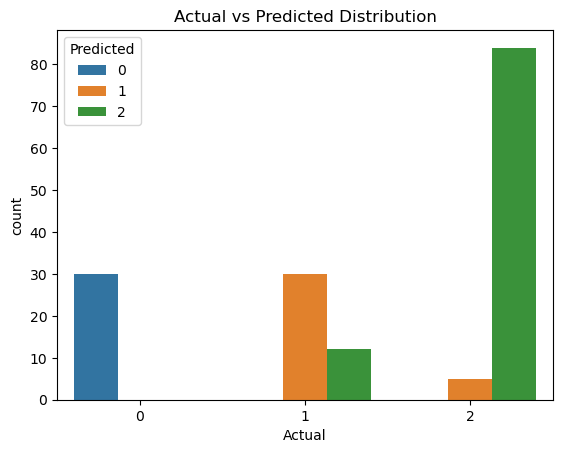

In [22]:
sns.countplot(x="Actual", hue="Predicted", data=comparison)
plt.title("Actual vs Predicted Distribution")
plt.show()

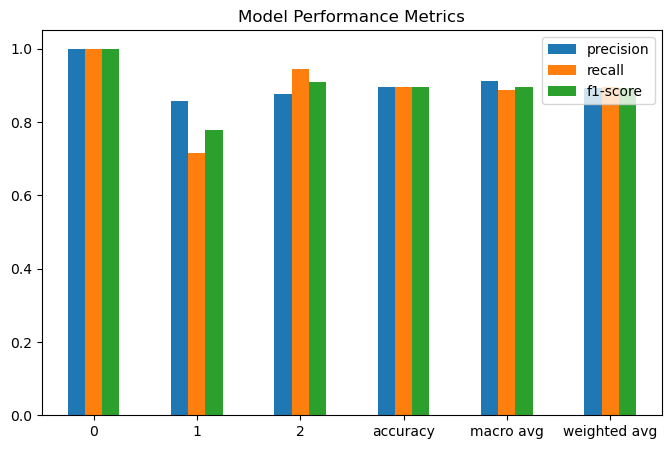

In [23]:
#precision recall f1 visualization
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_rf, output_dict=True)
report_df = pd.DataFrame(report).transpose()

report_df[['precision','recall','f1-score']].plot(kind='bar', figsize=(8,5))
plt.title("Model Performance Metrics")
plt.xticks(rotation=0)
plt.show()

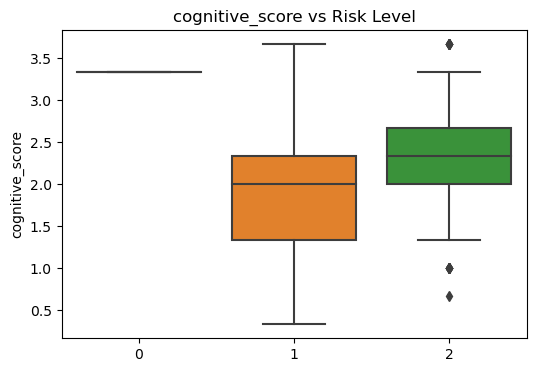

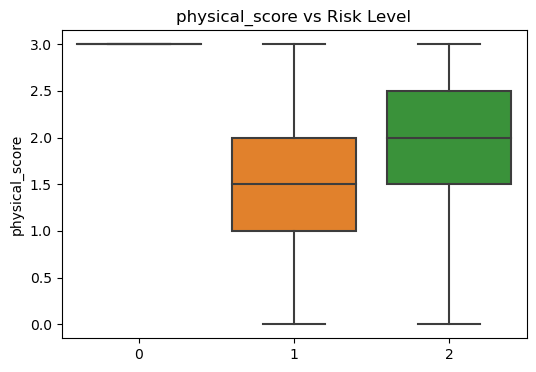

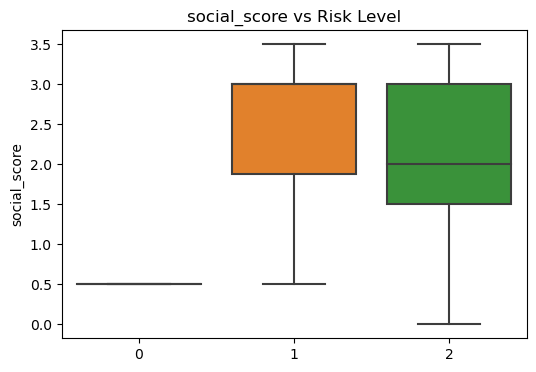

In [25]:
top_features = feat_df.head(3)['Feature']

for col in top_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=y, y=X[col])
    plt.title(f"{col} vs Risk Level")
    plt.show()
    
    #boxplot shows why medium overlaps with high

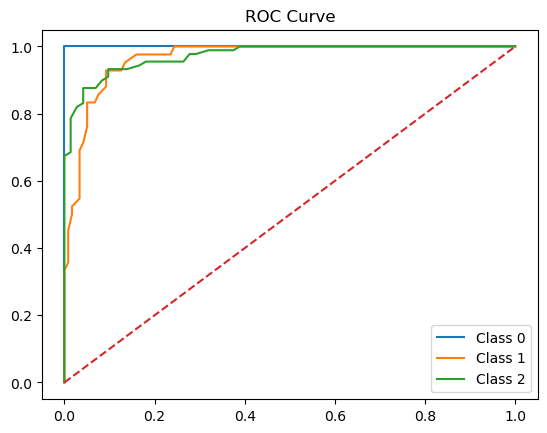

In [27]:
#ROC curve
#imaginary line is the guessing line
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0,1,2])

y_probs = rf.predict_proba(X_test)

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, label=f'Class {i}')

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

C:\Users\MS994\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\MS994\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\MS994\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\MS994\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\MS994\anaconda3\Lib\site-packages\sklearn\clust

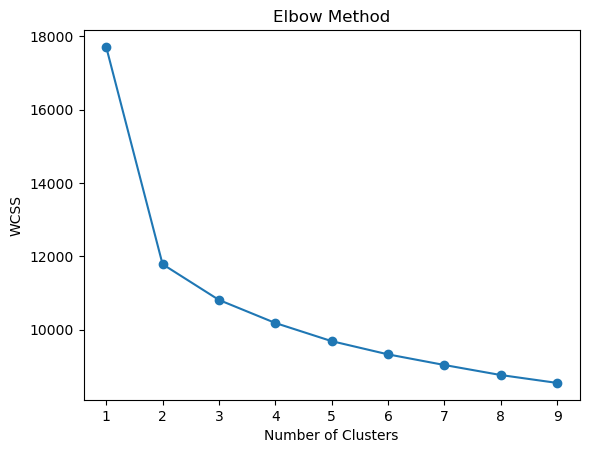

In [32]:
#descriptive modelling

from sklearn.cluster import KMeans
X_cluster = df.drop(columns=["risk_level"])

X_cluster = X_cluster.select_dtypes(include=['number'])
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

#ELBOW METHOD
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.plot(range(1,10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [33]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

C:\Users\MS994\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


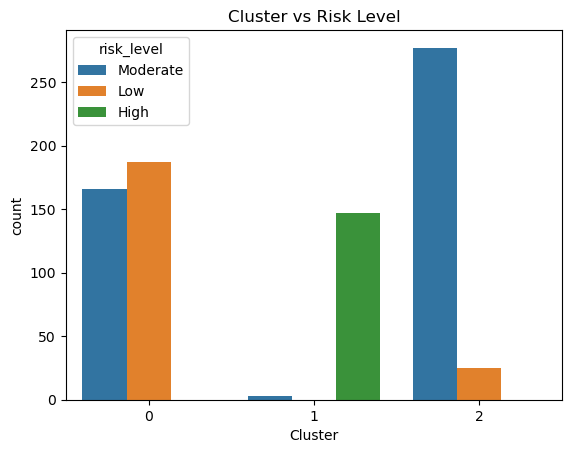

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Cluster", hue="risk_level", data=df)
plt.title("Cluster vs Risk Level")
plt.show()

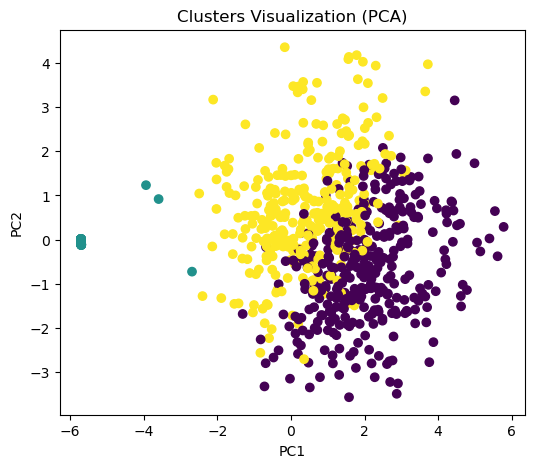

In [35]:
#PCA Visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Clusters Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [37]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)
print(cluster_profile)

               age    stress   anxiety   sadness  overwhelmed  concentration  \
Cluster                                                                        
0        31.923513  2.450425  2.354108  2.084986     1.067989       1.980170   
1        32.453333  3.993333  3.986667  3.980000     2.993333       3.006667   
2        33.480132  2.513245  2.218543  2.370861     2.350993       2.735099   

         overthinking  mood_swings     tired   support  ...  wellbeing  \
Cluster                                                 ...              
0            2.464589     1.603399  2.450425  2.365439  ...   3.424929   
1            4.000000     2.993333  3.986667  0.040000  ...   1.026667   
2            2.956954     1.884106  2.678808  1.513245  ...   3.307947   

            sleep  emotional_score  cognitive_score  sleep_risk  \
Cluster                                                           
0        0.974504         2.296506         1.837583    1.025496   
1        0.006667         3